正在读取数据...
原始最小/最大: 1.5669854747102363e-06 1.0000000200408773e+20
转换后 (ppb) 最小/最大: 1566.9854736328125 1999.4759521484375


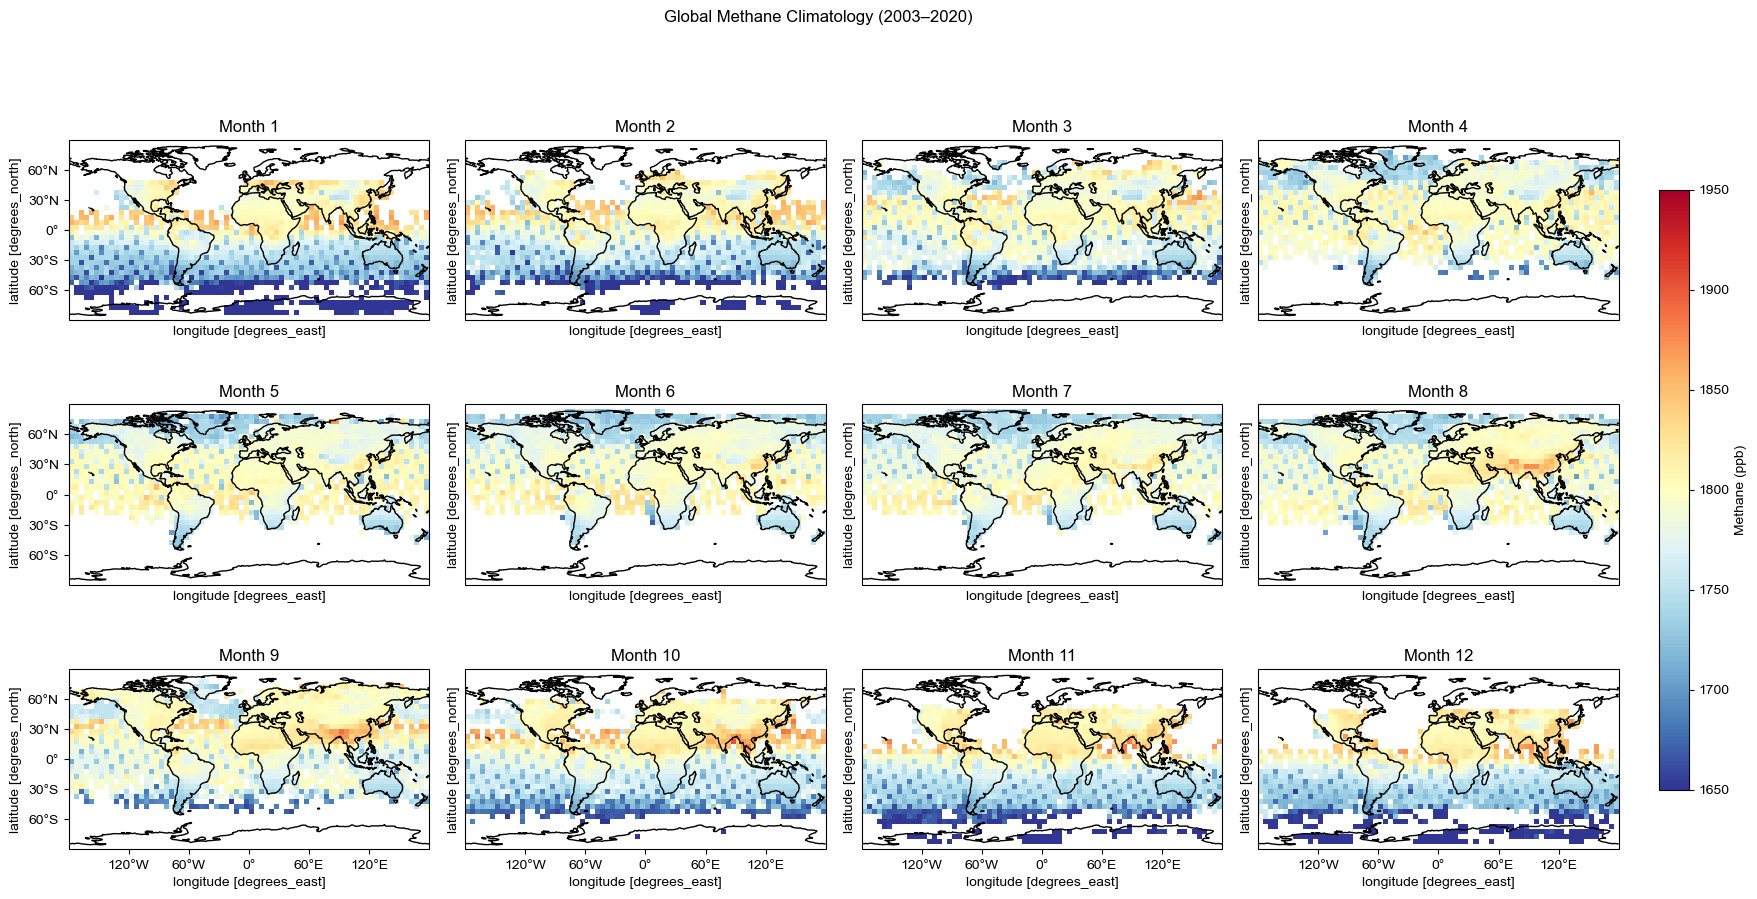

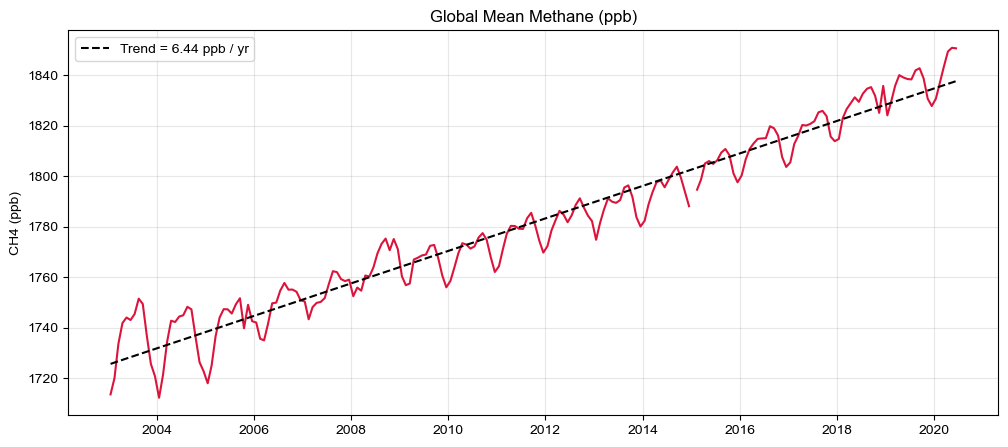

原始有效数据比例: <xarray.DataArray 'xch4' ()> Size: 8B
array(0.36666667)
Coordinates:
    lat      float64 8B -12.5
    lon      float64 8B -147.5
QC 过滤后有效比例: <xarray.DataArray 'xch4' ()> Size: 8B
array(0.23809524)
Coordinates:
    lat      float64 8B -12.5
    lon      float64 8B -147.5
最终有效数据覆盖: 2003-11-16T00:00:00.000000000 → 2019-12-16T12:00:00.000000000


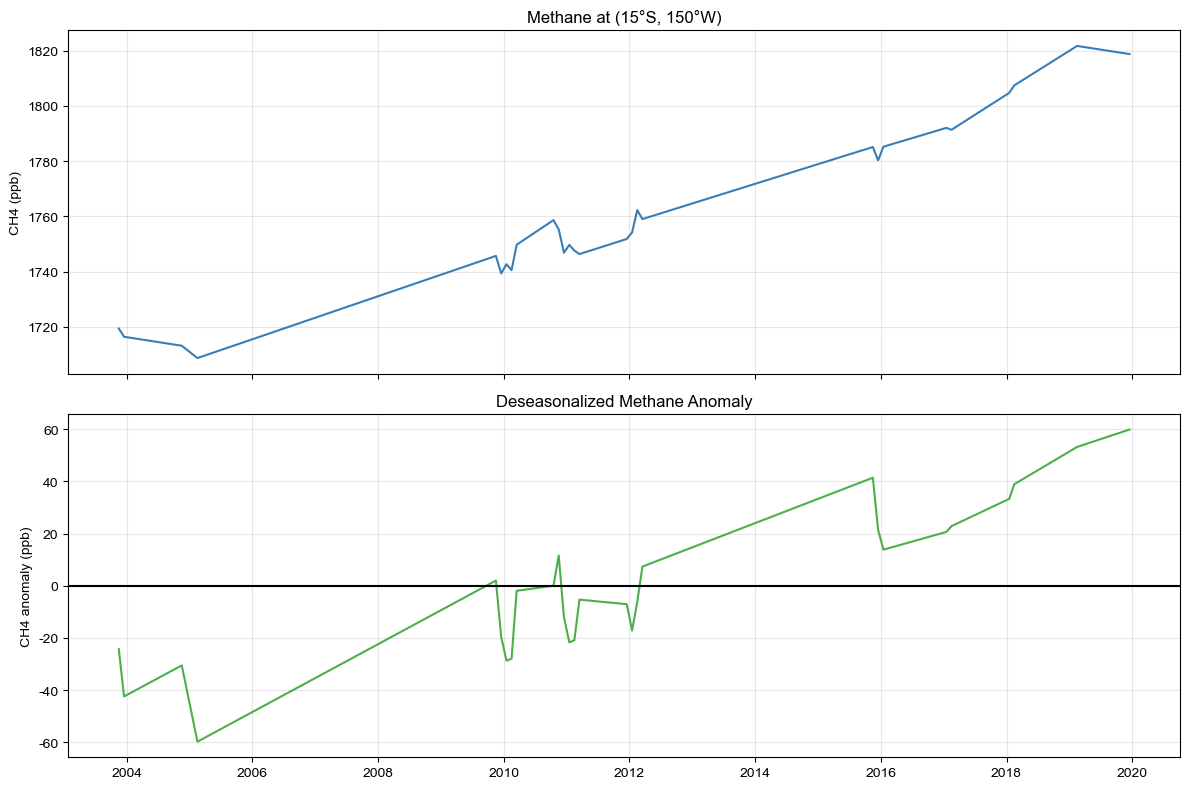

In [ ]:
# ============================================================
# Problem 1: Global Methane Analysis (2003–2020) 
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

plt.rcParams['font.sans-serif']=['Arial']
plt.rcParams['axes.unicode_minus']=False

# ============================================================
# 1. 读取数据 + 正确处理单位
# ============================================================

file_path = "200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc"
print("正在读取数据...")

ds = xr.open_dataset(file_path)

methane_raw = ds["xch4"]

print("原始最小/最大:", float(methane_raw.min()), float(methane_raw.max()))

# Step 1 — 去除 fill value (C3S 标准缺测 = 1e20)
methane_clean = methane_raw.where(methane_raw < 1e10)

# Step 2 — 转换为 ppb（mol/mol × 1e9）
methane = methane_clean * 1e9

print("转换后 (ppb) 最小/最大:", float(methane.min()), float(methane.max()))

# ============================================================
# 1.1 Climatology（12 panel）
# ============================================================

climatology = methane.groupby("time.month").mean("time")

fig, axes = plt.subplots(3, 4, figsize=(20,10),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten()

# Colorbar 范围与标准答案一致
vmin, vmax = 1650, 1950

for i in range(12):
    ax = axes[i]
    pcm = climatology.sel(month=i+1).plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap="RdYlBu_r", vmin=vmin, vmax=vmax,
        add_colorbar=False, shading="auto"
    )
    ax.set_title(f"Month {i+1}")
    ax.coastlines()

    if i >= 8:
        ax.set_xticks([-120, -60, 0, 60, 120], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
    else:
        ax.set_xticks([])

    if i % 4 == 0:
        ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
    else:
        ax.set_yticks([])

plt.subplots_adjust(wspace=0.1, hspace=0.1)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(pcm, cax=cbar_ax, label="Methane (ppb)")

plt.suptitle("Global Methane Climatology (2003–2020)")
plt.show()

# ============================================================
# 1.2 Global mean methane (time series)
# ============================================================

weights = np.cos(np.deg2rad(methane.lat))
global_mean = methane.weighted(weights).mean(("lat","lon"))

# 趋势必须剔除 NaN
valid = ~np.isnan(global_mean.values)
x = np.arange(len(global_mean))[valid]
y = global_mean.values[valid]

# 线性趋势
z = np.polyfit(x, y, 1)
trend = np.poly1d(z)(x)

plt.figure(figsize=(12,5))
plt.plot(global_mean.time, global_mean, color="crimson", lw=1.5)
plt.plot(global_mean.time[valid], trend, "k--", lw=1.5,
         label=f"Trend = {z[0]*12:.2f} ppb / yr")

plt.title("Global Mean Methane (ppb)")
plt.ylabel("CH4 (ppb)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 1.3 Deseasonalized methane at (15S, 150W)
# ============================================================

target_lat, target_lon = -15, -150
point_raw = methane.sel(lat=target_lat, lon=target_lon, method="nearest")

# 加载辅助质量参数
nobs_point = ds["xch4_nobs"].sel(lat=target_lat, lon=target_lon, method="nearest")
stderr_point = ds["xch4_stderr"].sel(lat=target_lat, lon=target_lon, method="nearest")

# 官方 C3S 推荐过滤规则
# 规则：有效观测 > 10，误差 < 50 ppb
point_qc = point_raw.where((nobs_point > 10) & (stderr_point < 50))

print("原始有效数据比例:", 1 - np.isnan(point_raw).mean())
print("QC 过滤后有效比例:", 1 - np.isnan(point_qc).mean())

# 额外去掉奇怪 spike：差值超过 40ppb 的点（可选但非常有效）
point_clean = point_qc.where(abs(point_qc - point_qc.shift(time=1)) < 40)

# 只在真正有数据的时间段画图
point_final = point_clean.dropna(dim="time")

print("最终有效数据覆盖:", point_final.time.values[0], "→", point_final.time.values[-1])

# 计算季节循环 & 去季节化
clim_point = point_final.groupby("time.month").mean()
deseason = point_final.groupby("time.month") - clim_point

# 绘图
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(point_final.time, point_final, color="#377eb8", lw=1.5)
axs[0].set_title("Methane at (15°S, 150°W)")
axs[0].set_ylabel("CH4 (ppb)")
axs[0].grid(alpha=0.3)

axs[1].plot(deseason.time, deseason, color="#4daf4a", lw=1.5)
axs[1].axhline(0, color="black")
axs[1].set_title("Deseasonalized Methane Anomaly")
axs[1].set_ylabel("CH4 anomaly (ppb)")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


正在读取SST数据...
SST数据形状: (684, 89, 180)

1.1 计算Nino 3.4区域的SST气候态和异常...
Niño 3.4 SST时间序列长度: 684
月度气候态值:
Month 1: 26.57°C
Month 2: 26.74°C
Month 3: 27.24°C
Month 4: 27.69°C
Month 5: 27.80°C
Month 6: 27.60°C
Month 7: 27.20°C
Month 8: 26.82°C
Month 9: 26.74°C
Month 10: 26.72°C
Month 11: 26.69°C
Month 12: 26.61°C

1.2 绘制Nino 3.4指数图...


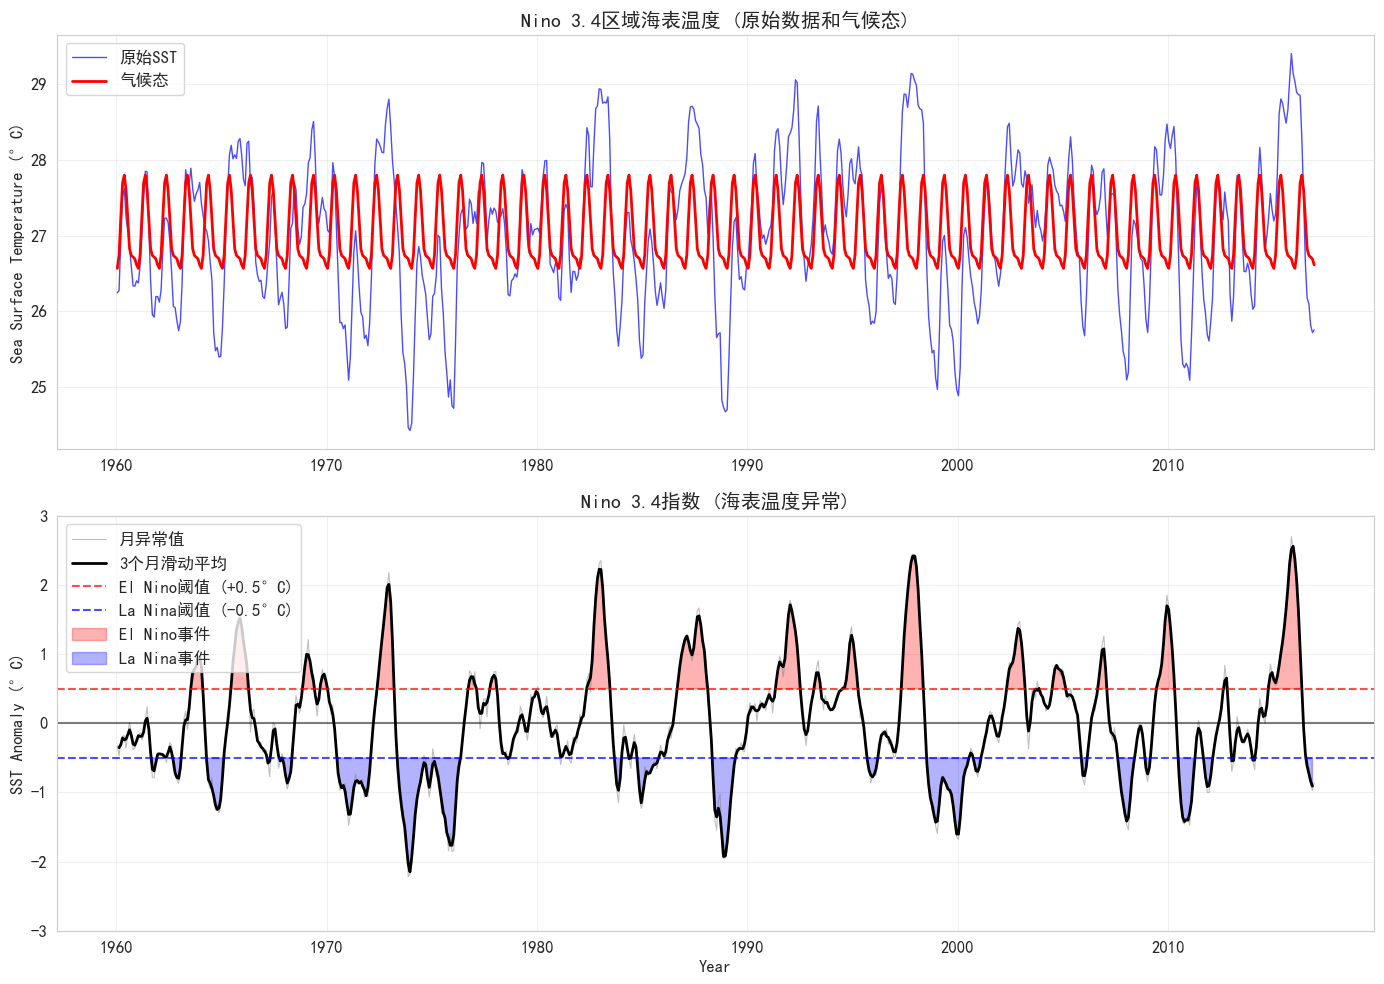


Niño 3.4指数统计:
时间范围: 1960-01-15T00:00:00.000000000 到 2016-12-15T00:00:00.000000000
SST平均值: 27.04°C
SST异常范围: -2.22 到 2.70°C
3个月滑动平均范围: -2.15 到 2.56°C


In [ ]:
## problem 2: Nino 3.4 Index Calculation and Visualization
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd

# 设置中文字体和绘图样式
import matplotlib as mpl
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 多个备选字体
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12

# 确保matplotlib使用中文字体
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['SimHei', 'Microsoft YaHei', 'DejaVu Sans'],
    'axes.unicode_minus': False
})

# 设置绘图样式
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 8)

# 1. 读取数据
print("正在读取SST数据...")
file_path = "NOAA_NCDC_ERSST_v3b_SST.nc"
ds = xr.open_dataset(file_path)

# 提取SST数据
sst = ds['sst']
print(f"SST数据形状: {sst.shape}")

# 2.1 计算Niño 3.4区域的气候态和异常值
print("\n1.1 计算Nino 3.4区域的SST气候态和异常...")

# 定义Niño 3.4区域 (5N-5S, 170W-120W)
nino34_region = sst.sel(lat=slice(-5, 5), lon=slice(190, 240))

# 计算区域平均SST (考虑纬度权重)
weights = np.cos(np.deg2rad(nino34_region.lat))
weights.name = "weights"
nino34_sst = nino34_region.weighted(weights).mean(dim=['lat', 'lon'])

print(f"Niño 3.4 SST时间序列长度: {len(nino34_sst)}")

# 计算月度气候态
climatology = nino34_sst.groupby('time.month').mean()

print("月度气候态值:")
for month in range(1, 13):
    print(f"Month {month}: {climatology.sel(month=month).values:.2f}°C")

# 计算异常值 (当前值 - 气候态)
nino34_anomalies = nino34_sst.groupby('time.month') - climatology

# 计算3个月滑动平均 (ENSO标准)
nino34_3month = nino34_anomalies.rolling(time=3, center=True).mean()

# 2.2 可视化Niño 3.4指数
print("\n1.2 绘制Nino 3.4指数图...")

# 创建图形
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

years = nino34_sst.time.dt.year + (nino34_sst.time.dt.month - 0.5) / 12

# Plot 1: 原始SST和气候态
ax1.plot(years, nino34_sst, linewidth=1, color='blue', alpha=0.7, label='原始SST')

# 修复：为气候态创建匹配的时间序列
climatology_series = []
for time_point in nino34_sst.time:
    month = time_point.dt.month.values
    climatology_series.append(climatology.sel(month=month).values)

ax1.plot(years, climatology_series, linewidth=2, color='red', label='气候态')

ax1.set_ylabel('Sea Surface Temperature (°C)')
ax1.set_title('Nino 3.4区域海表温度 (原始数据和气候态)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: 异常值和3个月滑动平均
# 绘制原始异常值
ax2.plot(years, nino34_anomalies, linewidth=0.8, color='gray', alpha=0.5, label='月异常值')

# 绘制3个月滑动平均
ax2.plot(years, nino34_3month, linewidth=2, color='black', label='3个月滑动平均')

# 添加ENSO阈值线
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='El Nino阈值 (+0.5°C)')
ax2.axhline(y=-0.5, color='blue', linestyle='--', alpha=0.7, label='La Nina阈值 (-0.5°C)')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 填充El Niño区域 (异常值 > 0.5°C)
ax2.fill_between(years, 0.5, nino34_3month, where=(nino34_3month >= 0.5), 
                color='red', alpha=0.3, label='El Nino事件')

# 填充La Niña区域 (异常值 < -0.5°C)
ax2.fill_between(years, -0.5, nino34_3month, where=(nino34_3month <= -0.5), 
                color='blue', alpha=0.3, label='La Nina事件')

ax2.set_xlabel('Year')
ax2.set_ylabel('SST Anomaly (°C)')
ax2.set_title('Nino 3.4指数 (海表温度异常)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-3, 3])

plt.tight_layout()
plt.show()

# 计算统计信息
print(f"\nNiño 3.4指数统计:")
print(f"时间范围: {nino34_sst.time.min().values} 到 {nino34_sst.time.max().values}")
print(f"SST平均值: {nino34_sst.mean().values:.2f}°C")
print(f"SST异常范围: {nino34_anomalies.min().values:.2f} 到 {nino34_anomalies.max().values:.2f}°C")
print(f"3个月滑动平均范围: {nino34_3month.min().values:.2f} 到 {nino34_3month.max().values:.2f}°C")

# 关闭数据集
ds.close()

c:\Users\Lzy20\conda_envs\clean\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


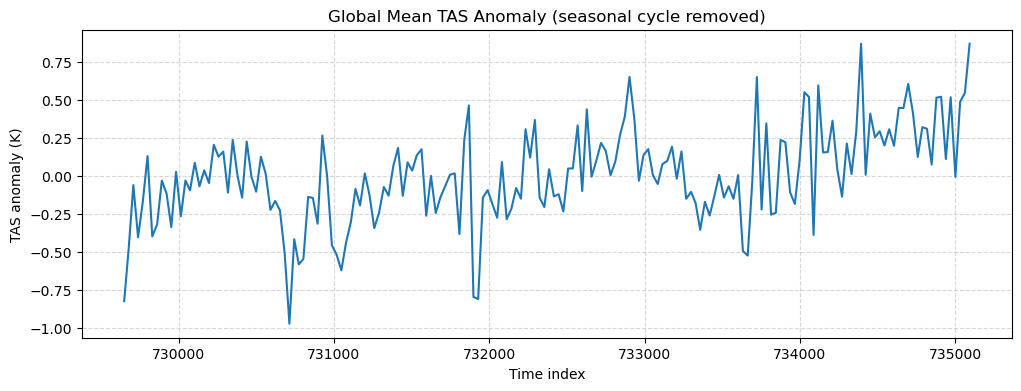

c:\Users\Lzy20\conda_envs\clean\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


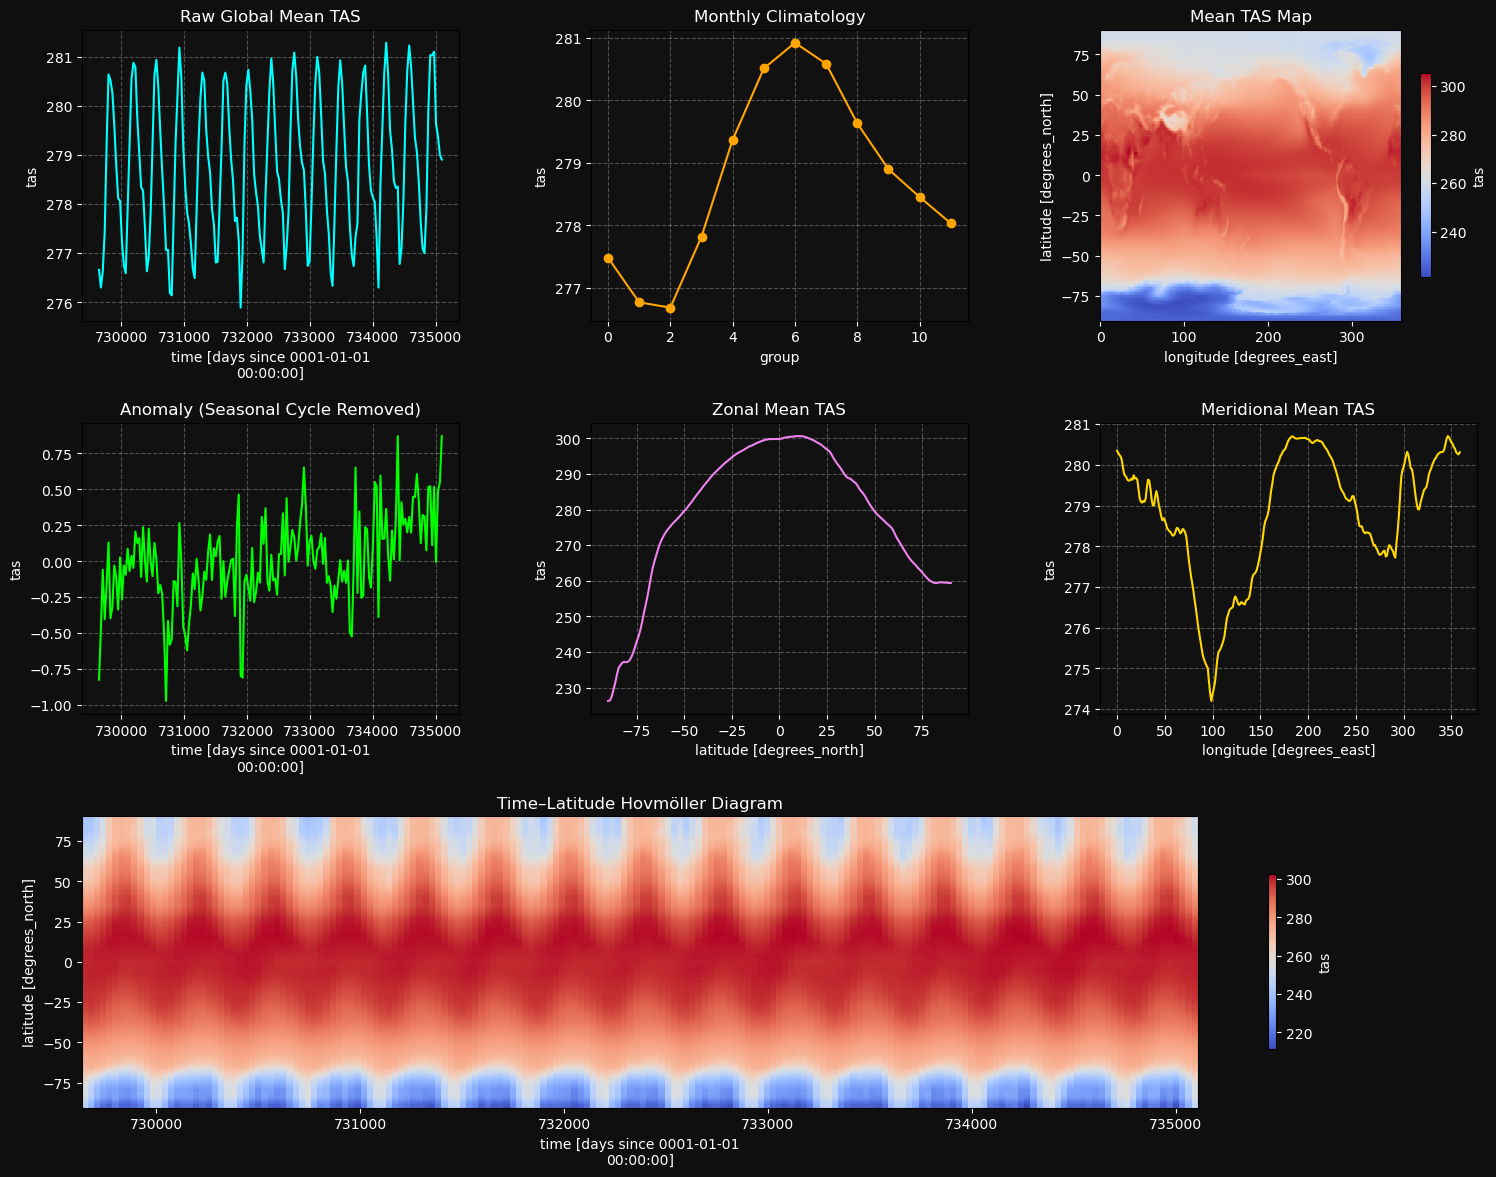

In [ ]:
## Problem 3 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
ds = xr.open_dataset("CESM2_200001-201412.nc", decode_times=False)

tas = ds["tas"]   # near-surface air temperature
lat = ds["lat"]
lon = ds["lon"]
time = ds["time"]

# 计算全球平均温度
ts = tas.mean(dim=("lat", "lon"))

# 构造 month index（因为 decode_times=False, noleap calendar）
month_index = np.arange(ts.sizes["time"]) % 12
month_da = xr.DataArray(month_index, dims=["time"])

## Problem 1 季节循环去除的时间序列

# 计算 climatology（12 个月平均）
clim = ts.groupby(month_da).mean()

# 计算 anomaly
anom = ts.groupby(month_da) - clim

# 绘图
plt.figure(figsize=(12,4))
anom.plot()
plt.title("Global Mean TAS Anomaly (seasonal cycle removed)")
plt.xlabel("Time index")
plt.ylabel("TAS anomaly (K)")
plt.grid(True, ls="--", alpha=0.5)
plt.show()

## Problem 2 Plot 7 pictures in one figure
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load CESM2 dataset
ds = xr.open_dataset("CESM2_200001-201412.nc", decode_times=False)

tas = ds["tas"]
lat = ds["lat"]
lon = ds["lon"]
time = ds["time"]

# Global mean time series
ts = tas.mean(dim=("lat", "lon"))

# Construct month index (since decode_times=False)
month_index = np.arange(ts.sizes["time"]) % 12
month_da = xr.DataArray(month_index, dims=["time"])

# Seasonal climatology
clim = ts.groupby(month_da).mean()
anom = ts.groupby(month_da) - clim

# Other fields
mean_map = tas.mean(dim="time")
zonal = tas.mean(dim=("time", "lon"))
merid = tas.mean(dim=("time", "lat"))
hov = tas.mean(dim="lon")

# ---------------------------------------------------------
# Create Big Composite Figure (7 subplots + dark mode)
# ---------------------------------------------------------

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, wspace=0.35, hspace=0.35)

# ----------------------
# Plot 1: Raw Time Series
# ----------------------
ax1 = fig.add_subplot(gs[0, 0])
ts.plot(ax=ax1, color="cyan")
ax1.set_title("Raw Global Mean TAS")
ax1.grid(True, ls="--", alpha=0.4)

# ----------------------
# Plot 2: Monthly Climatology
# ----------------------
ax2 = fig.add_subplot(gs[0, 1])
clim.plot(ax=ax2, marker="o", color="orange")
ax2.set_title("Monthly Climatology")
ax2.grid(True, ls="--", alpha=0.4)

# ----------------------
# Plot 3: Mean TAS Map
# ----------------------
ax3 = fig.add_subplot(gs[0, 2])
mean_map.plot(ax=ax3, cmap="coolwarm", cbar_kwargs={'shrink':0.7})
ax3.set_title("Mean TAS Map")

# ----------------------
# Plot 4: Anomaly Time Series
# ----------------------
ax4 = fig.add_subplot(gs[1, 0])
anom.plot(ax=ax4, color="lime")
ax4.set_title("Anomaly (Seasonal Cycle Removed)")
ax4.grid(True, ls="--", alpha=0.4)

# ----------------------
# Plot 5: Zonal Mean
# ----------------------
ax5 = fig.add_subplot(gs[1, 1])
zonal.plot(ax=ax5, color="violet")
ax5.set_title("Zonal Mean TAS")
ax5.grid(True, ls="--", alpha=0.4)

# ----------------------
# Plot 6: Meridional Mean
# ----------------------
ax6 = fig.add_subplot(gs[1, 2])
merid.plot(ax=ax6, color="gold")
ax6.set_title("Meridional Mean TAS")
ax6.grid(True, ls="--", alpha=0.4)

# ----------------------
# Plot 7: Hovmöller Diagram
# ----------------------
ax7 = fig.add_subplot(gs[2, :])
hov.plot(x="time", y="lat", ax=ax7, cmap="coolwarm", cbar_kwargs={'shrink':0.6})
ax7.set_title("Time–Latitude Hovmöller Diagram")

# ----------------------
# Dark mode aesthetic enhancements
# ----------------------
fig.patch.set_facecolor("#0f0f0f")  # dark background

for ax in fig.axes:
    ax.set_facecolor("#111111")     # dark subplot background
    ax.title.set_color("white")      # title text color
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")   # tick color

plt.show()
